# 02 — Grounding DINO: Improved Player Detection

Validates GDINO-guided extraction on specific frames with known skeleton errors.

**Known bad frames:**
- `0011_001` T=16474 — P0 centroid at x≈102 (chair umpire on left edge, not a player)
- `0011_001` T=16485 — same issue

**Output:** 4-column grid per frame: Raw | Original skeleton | GDINO boxes | GDINO-guided skeleton

Add more `(rally_id, abs_frame)` pairs to `KNOWN_BAD` as you discover them.

## 0. Setup

In [1]:
!pip install -q "transformers>=5.0.0" timm pillow

In [2]:
import sys
sys.path.insert(0, '..')

import cv2, json, numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from src.config import FB_FRAMES, FB_ANNOTATIONS, PROJECT_ROOT

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GDINO_OUT = PROJECT_ROOT / 'results' / 'grounding_dino'
GDINO_OUT.mkdir(parents=True, exist_ok=True)

with open(FB_ANNOTATIONS) as f:
    _ann = json.load(f)
RALLY_START = {r['video'].replace('.mp4', ''): r['start_frame'] for r in _ann}

print(f'Device: {DEVICE} | Rallies: {len(RALLY_START)}')

Device: cpu | Rallies: 40


## 1. Load Grounding DINO

In [3]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import transformers
print(f'transformers {transformers.__version__}')

MODEL_ID       = 'IDEA-Research/grounding-dino-tiny'  # swap to grounding-dino-base for higher recall
BOX_THRESHOLD  = 0.30
TEXT_THRESHOLD = 0.25
GDINO_PROMPT   = 'badminton player .'  # more specific — avoids umpire/ball kids   # try 'badminton player .' if this is too broad

processor = AutoProcessor.from_pretrained(MODEL_ID)
gdino     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
gdino.eval()
print(f'Loaded {MODEL_ID.split("/")[-1]} on {DEVICE}')

transformers 5.2.0


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Loaded grounding-dino-tiny on cpu


## 2. Helpers

In [4]:
COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]
PLAYER_COLORS = [(0,200,255), (255,120,0)]   # P0=cyan, P1=orange

_skel_cache = {}

def load_frame(rally_id, abs_frame):
    p = FB_FRAMES / f'{rally_id}_{abs_frame}.jpg'
    img = cv2.imread(str(p))
    if img is None: raise FileNotFoundError(p)
    return img

def load_skeleton(rally_id):
    if rally_id not in _skel_cache:
        p = PROJECT_ROOT / 'datasets_preprocessing' / 'finebadminton_skeletons' / f'{rally_id}.npy'
        _skel_cache[rally_id] = np.load(p)
    return _skel_cache[rally_id]

def draw_skeleton(bgr, sf):
    """sf: (2,34) row0=x, row1=y; joints 0-16=P0, 17-33=P1. Returns RGB."""
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
    ov  = img.copy()
    for p, col in enumerate(PLAYER_COLORS):
        b = p * 17
        xs, ys = sf[0, b:b+17], sf[1, b:b+17]
        for j1, j2 in COCO_EDGES:
            x1,y1,x2,y2 = int(xs[j1]),int(ys[j1]),int(xs[j2]),int(ys[j2])
            if x1>0 and y1>0 and x2>0 and y2>0:
                cv2.line(ov,(x1,y1),(x2,y2),col,2,cv2.LINE_AA)
        for j in range(17):
            x,y = int(xs[j]),int(ys[j])
            if x>0 and y>0:
                cv2.circle(ov,(x,y),5,col,-1,cv2.LINE_AA)
                cv2.circle(ov,(x,y),5,(255,255,255),1,cv2.LINE_AA)
        ok = (xs>0)&(ys>0)
        if ok.any():
            cx,cy = int(xs[ok].mean()),int(ys[ok].mean())
            cv2.putText(ov,f'P{p}',(cx-10,cy-14),cv2.FONT_HERSHEY_SIMPLEX,0.7,col,2)
    return cv2.addWeighted(ov,0.85,img,0.15,0)

@torch.no_grad()
def gdino_detect(bgr, prompt, box_thresh=BOX_THRESHOLD, text_thresh=TEXT_THRESHOLD):
    """Run GDINO. Returns (boxes N×4, scores N, labels list[str])."""
    rgb    = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    H, W   = bgr.shape[:2]
    inp    = processor(images=Image.fromarray(rgb), text=prompt,
                       return_tensors='pt').to(DEVICE)
    out    = gdino(**inp)
    # transformers 5.x: 'box_threshold' renamed to 'threshold'
    res    = processor.post_process_grounded_object_detection(
        outputs=out,
        input_ids=inp['input_ids'],
        threshold=box_thresh,
        text_threshold=text_thresh,
        target_sizes=[(H, W)]
    )[0]
    return res['boxes'].cpu().numpy(), res['scores'].cpu().numpy(), res['labels']

def _iou(b1, b2):
    ix1,iy1 = max(b1[0],b2[0]),max(b1[1],b2[1])
    ix2,iy2 = min(b1[2],b2[2]),min(b1[3],b2[3])
    iw,ih   = max(0,ix2-ix1),max(0,iy2-iy1)
    inter   = iw*ih
    return inter/((b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter+1e-9)

print('Helpers ready.')

Helpers ready.


In [5]:
_yolo = None
_gdino_skel_cache = {}  # (rally_id, abs_frame) -> (2,34)

def get_yolo():
    global _yolo
    if _yolo is None:
        from ultralytics import YOLO
        _yolo = YOLO('yolov8x-pose.pt')
        print('YOLOv8x-pose loaded')
    return _yolo

def extract_gdino_skeleton(bgr, prompt=None, iou_thresh=0.25):
    """
    GDINO-guided skeleton for one frame. Returns (2,34): row0=x, row1=y.
    Joints 0-16 = P0 (top court), 17-33 = P1 (bottom court).

    Steps:
      1. GDINO -> player bbox priors
      2. YOLOv8-pose full frame
      3. Keep YOLO persons with IoU >= iou_thresh vs any GDINO prior
      4. Y-sort top-2 retained detections
      Fallback: plain YOLOv8 top-2 if GDINO finds fewer than 2 players.
    """
    if prompt is None: prompt = GDINO_PROMPT
    yolo = get_yolo()

    g_boxes, _, g_labels = gdino_detect(bgr, prompt)
    pmask    = np.array([l == 'person' for l in g_labels], dtype=bool)
    g_player = g_boxes[pmask] if pmask.any() else g_boxes

    res    = yolo(bgr, verbose=False)[0]
    out_sf = np.zeros((2, 34), dtype=np.float32)
    if res is None or res.keypoints is None or res.boxes is None:
        return out_sf

    y_boxes = res.boxes.xyxy.cpu().numpy()    # (N,4)
    y_cls   = res.boxes.cls.cpu().numpy()     # (N,)
    y_kpts  = res.keypoints.xy.cpu().numpy()  # (N,17,2)
    y_confs = res.boxes.conf.cpu().numpy()    # (N,)

    kept_kpts, kept_confs, kept_cy = [], [], []
    for i, (yb, yc, yconf) in enumerate(zip(y_boxes, y_cls, y_confs)):
        if int(yc) != 0: continue
        max_iou = max((_iou(yb, gb) for gb in g_player), default=0.0)
        if max_iou >= iou_thresh:
            kept_kpts.append(y_kpts[i])
            kept_confs.append(float(yconf))
            kept_cy.append(float(y_kpts[i][:, 1].mean()))

    if len(kept_kpts) < 2:
        print(f'  [FALLBACK] GDINO kept {len(kept_kpts)} player(s) — using plain YOLOv8 top-2')
        pmask2 = y_cls == 0
        if pmask2.sum() >= 2:
            order     = np.argsort(y_confs[pmask2])[::-1][:2]
            pkpts     = y_kpts[pmask2]
            kept_kpts = [pkpts[i] for i in order]
            kept_cy   = [float(kept_kpts[i][:, 1].mean()) for i in range(2)]
        else:
            return out_sf

    if len(kept_kpts) > 2:
        order     = np.argsort(kept_confs)[::-1][:2]
        kept_kpts = [kept_kpts[i] for i in order]
        kept_cy   = [kept_cy[i]   for i in order]

    ys = np.argsort(kept_cy)
    p0, p1 = kept_kpts[ys[0]], kept_kpts[ys[1]]
    out_sf[0,:17]=p0[:,0]; out_sf[1,:17]=p0[:,1]
    out_sf[0,17:]=p1[:,0]; out_sf[1,17:]=p1[:,1]
    return out_sf

def get_gdino_skel(rally_id, abs_frame):
    """Cached GDINO-guided extraction."""
    key = (rally_id, abs_frame)
    if key not in _gdino_skel_cache:
        bgr = load_frame(rally_id, abs_frame)
        _gdino_skel_cache[key] = extract_gdino_skeleton(bgr)
    return _gdino_skel_cache[key]

print('GDINO-guided extractor ready. YOLOv8 loads on first call.')

GDINO-guided extractor ready. YOLOv8 loads on first call.


## 3. Known-Bad Frame Analysis

Four columns: **Raw frame** | **Original skeleton** | **GDINO boxes** | **GDINO-guided skeleton**

Add more `(rally_id, abs_frame)` tuples to `KNOWN_BAD` as you find them.

0011_001  abs=16474  t=112
  ORIG  P0=(102,220)  P1=(731,288)


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


YOLOv8x-pose loaded


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  GDINO P0=(730,287)  P1=(794,440)
0011_001  abs=16485  t=123
  ORIG  P0=(98,219)  P1=(711,283)
  GDINO P0=(710,284)  P1=(866,503)


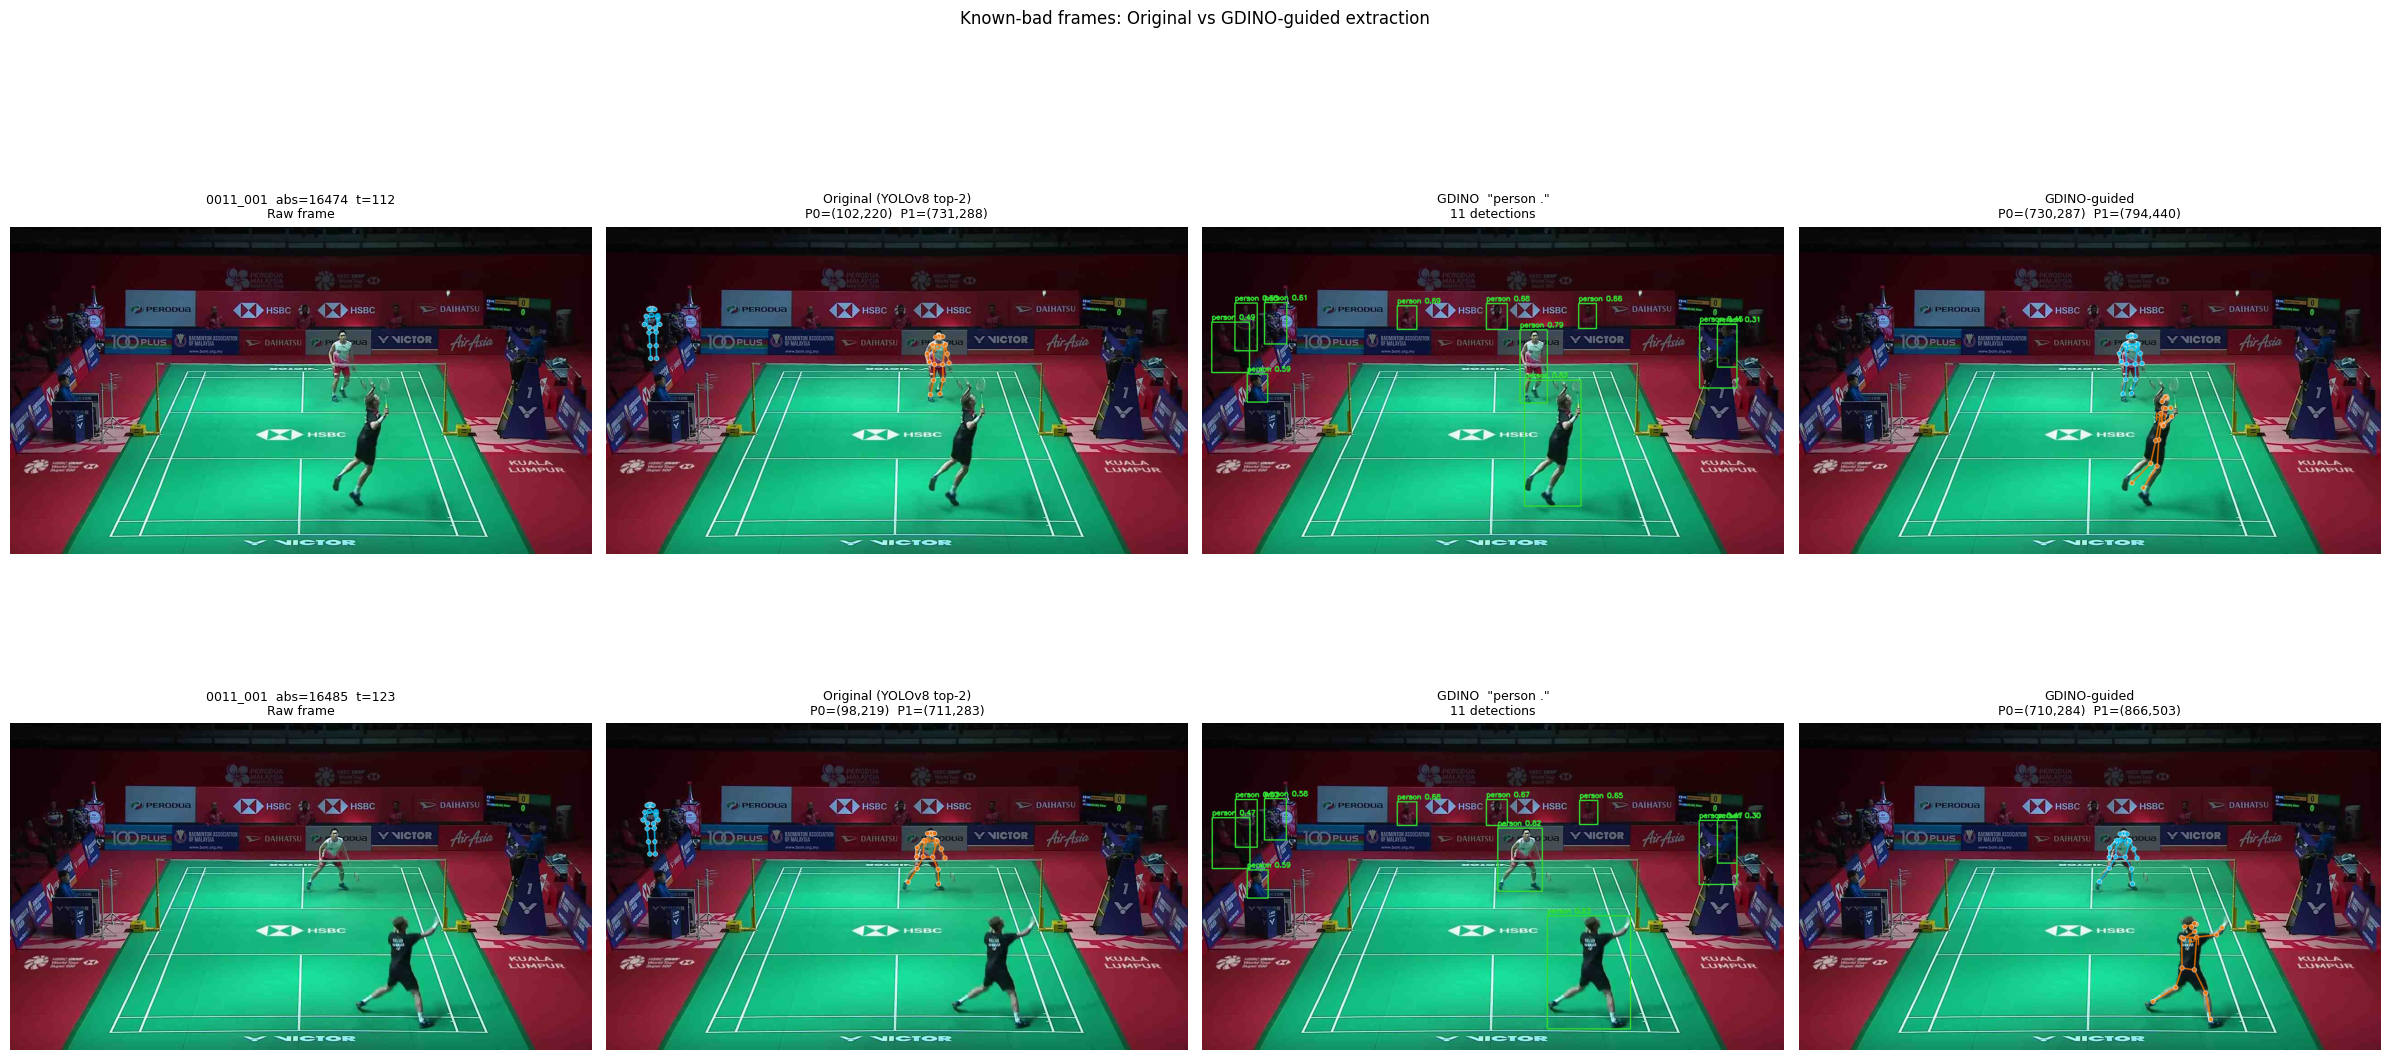

Saved -> /Users/yuen@backbase.com/Documents/Baddiev2/results/grounding_dino/known_bad_frames.png


In [6]:
KNOWN_BAD = [
    ('0011_001', 16474),
    ('0011_001', 16485),
    # ('0011_002', XXXXX),
]

fig, axes = plt.subplots(len(KNOWN_BAD), 4, figsize=(24, 6*len(KNOWN_BAD)))
if len(KNOWN_BAD) == 1:
    axes = axes[np.newaxis, :]

for row, (rally_id, abs_frame) in enumerate(KNOWN_BAD):
    skel    = load_skeleton(rally_id)                   # (2, T, 34)
    t       = abs_frame - RALLY_START[rally_id]         # index into npy
    bgr     = load_frame(rally_id, abs_frame)
    orig_sf = skel[:, t, :]                             # (2, 34)

    p0cx,p0cy = orig_sf[0,:17].mean(), orig_sf[1,:17].mean()
    p1cx,p1cy = orig_sf[0,17:].mean(), orig_sf[1,17:].mean()

    print(f'{rally_id}  abs={abs_frame}  t={t}')
    print(f'  ORIG  P0=({p0cx:.0f},{p0cy:.0f})  P1=({p1cx:.0f},{p1cy:.0f})')

    # Col 0: Raw
    axes[row,0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[row,0].set_title(f'{rally_id}  abs={abs_frame}  t={t}\nRaw frame', fontsize=9)
    axes[row,0].axis('off')

    # Col 1: Original skeleton
    axes[row,1].imshow(draw_skeleton(bgr, orig_sf))
    axes[row,1].set_title(
        f'Original (YOLOv8 top-2)\nP0=({p0cx:.0f},{p0cy:.0f})  P1=({p1cx:.0f},{p1cy:.0f})',
        fontsize=9)
    axes[row,1].axis('off')

    # Col 2: GDINO detections
    g_boxes, g_scores, g_labels = gdino_detect(bgr, GDINO_PROMPT)
    vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
    for box, score, label in zip(g_boxes, g_scores, g_labels):
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(vis,(x1,y1),(x2,y2),(50,220,50),2)
        cv2.putText(vis,f'{label} {score:.2f}',(x1,max(y1-6,10)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(50,220,50),2)
    axes[row,2].imshow(vis)
    axes[row,2].set_title(f'GDINO  "{GDINO_PROMPT}"\n{len(g_boxes)} detections', fontsize=9)
    axes[row,2].axis('off')

    # Col 3: GDINO-guided skeleton
    gdino_sf = get_gdino_skel(rally_id, abs_frame)
    gp0cx,gp0cy = gdino_sf[0,:17].mean(), gdino_sf[1,:17].mean()
    gp1cx,gp1cy = gdino_sf[0,17:].mean(), gdino_sf[1,17:].mean()
    axes[row,3].imshow(draw_skeleton(bgr, gdino_sf))
    axes[row,3].set_title(
        f'GDINO-guided\nP0=({gp0cx:.0f},{gp0cy:.0f})  P1=({gp1cx:.0f},{gp1cy:.0f})',
        fontsize=9)
    axes[row,3].axis('off')

    print(f'  GDINO P0=({gp0cx:.0f},{gp0cy:.0f})  P1=({gp1cx:.0f},{gp1cy:.0f})')

plt.suptitle('Known-bad frames: Original vs GDINO-guided extraction', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(GDINO_OUT / 'known_bad_frames.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved -> {GDINO_OUT}/known_bad_frames.png')